In [80]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf
from sklearn.metrics import f1_score 
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Dropout, Conv2D

# Automated License Plate Recognition (ALPR)
This notebook explains a full ALPR pipeline for a still image:
1. Detect the license plate region in the input image.
2. Segment individual characters from the plate.
3. Train a CNN model to recognize alphanumeric characters.
4. Merge predictions into a plate string and render it on the image.

In [81]:
# Loads the data required for detecting the license plates from cascade classifier.
plate_cascade = cv2.CascadeClassifier('../dataset/indian_license_plate.xml')
# add the path to 'india_license_plate.xml' file.

In [82]:
def detect_plate(img, text=''): # the function detects and perfors blurring on the number plate.
    plate_img = img.copy()
    roi = img.copy()
    plate_rect = plate_cascade.detectMultiScale(plate_img, scaleFactor = 1.2, minNeighbors = 7) # detects numberplates and returns the coordinates and dimensions of detected license plate's contours.
    for (x,y,w,h) in plate_rect:
        roi_ = roi[y:y+h, x:x+w, :] # extracting the Region of Interest of license plate for blurring.
        plate = roi[y:y+h, x:x+w, :]
        cv2.rectangle(plate_img, (x+2,y), (x+w-3, y+h-5), (51,181,155), 3) # finally representing the detected contours by drawing rectangles around the edges.
    if text!='':
        plate_img = cv2.putText(plate_img, text, (x-w//2,y-h//2), 
                                cv2.FONT_HERSHEY_COMPLEX_SMALL , 0.5, (51,181,155), 1, cv2.LINE_AA)
        
    return plate_img, plate # returning the processed image.

## Plate Detection Block
The `detect_plate` function uses a Cascade Classifier to localize the plate area.
- `detectMultiScale` returns bounding boxes `(x, y, w, h)` for plate candidates.
- A rectangle is drawn on the detected plate region.
- If `text` is provided, the predicted plate string is drawn near the plate.
- The function returns both the annotated full image and the cropped plate image.

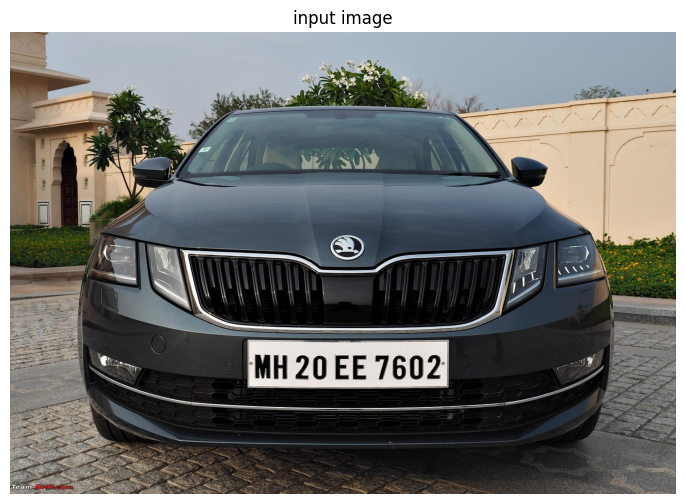

In [83]:
# Testing the above function
def display(img_, title=''):
    img = cv2.cvtColor(img_, cv2.COLOR_BGR2RGB)
    fig = plt.figure(figsize=(10,6))
    ax = plt.subplot(111)
    ax.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

img = cv2.imread('../dataset/car.jpg')
display(img, 'input image')

In [84]:
# Getting plate prom the processed image
output_img, plate = detect_plate(img)

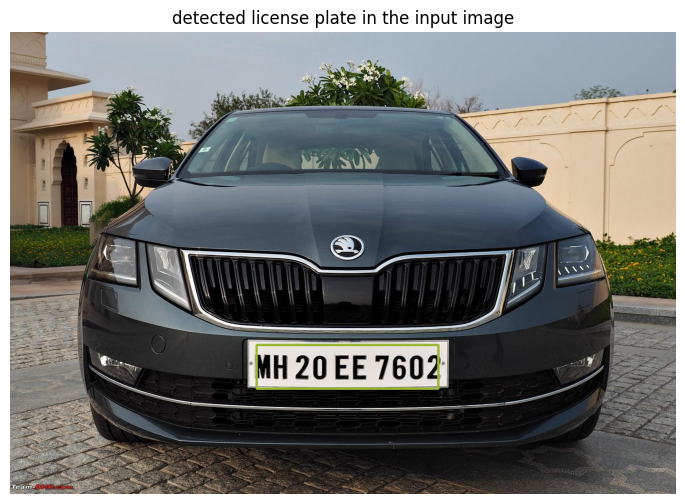

In [85]:
display(output_img, 'detected license plate in the input image')

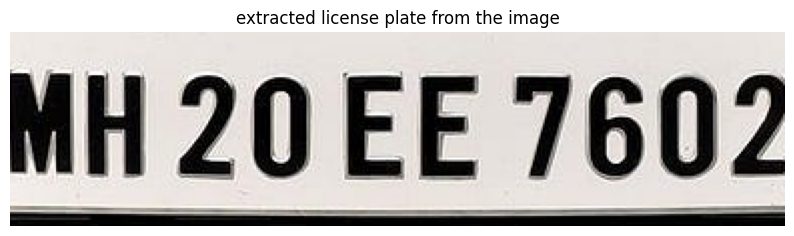

In [86]:
display(plate, 'extracted license plate from the image')

In [87]:
# Match contours to license plate or character template
def find_contours(dimensions, img) :

    # Find all contours in the image
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Retrieve potential dimensions
    lower_width = dimensions[0]
    upper_width = dimensions[1]
    lower_height = dimensions[2]
    upper_height = dimensions[3]
    
    # Check largest 5 or  15 contours for license plate or character respectively
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:15]
    
    ii = cv2.imread('contour.jpg')
    
    x_cntr_list = []
    target_contours = []
    img_res = []
    for cntr in cntrs :
        # detects contour in binary image and returns the coordinates of rectangle enclosing it
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
        
        # checking the dimensions of the contour to filter out the characters by contour's size
        if intWidth > lower_width and intWidth < upper_width and intHeight > lower_height and intHeight < upper_height :
            x_cntr_list.append(intX) #stores the x coordinate of the character's contour, to used later for indexing the contours

            char_copy = np.zeros((44,24))
            # extracting each character using the enclosing rectangle's coordinates.
            char = img[intY:intY+intHeight, intX:intX+intWidth]
            char = cv2.resize(char, (20, 40))
            
            cv2.rectangle(ii, (intX,intY), (intWidth+intX, intY+intHeight), (50,21,200), 2)
            plt.imshow(ii, cmap='gray')

            # Make result formatted for classification: invert colors
            char = cv2.subtract(255, char)

            # Resize the image to 24x44 with black border
            char_copy[2:42, 2:22] = char
            char_copy[0:2, :] = 0
            char_copy[:, 0:2] = 0
            char_copy[42:44, :] = 0
            char_copy[:, 22:24] = 0

            img_res.append(char_copy) # List that stores the character's binary image (unsorted)
            
    # Return characters on ascending order with respect to the x-coordinate (most-left character first)
            
    plt.show()
    # arbitrary function that stores sorted list of character indeces
    indices = sorted(range(len(x_cntr_list)), key=lambda k: x_cntr_list[k])
    img_res_copy = []
    for idx in indices:
        img_res_copy.append(img_res[idx])# stores character images according to their index
    img_res = np.array(img_res_copy)

    return img_res

In [88]:
# Find characters in the resulting images
def segment_characters(image) :

    # Preprocess cropped license plate image
    img_lp = cv2.resize(image, (333, 75))
    img_gray_lp = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY)
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    img_binary_lp = cv2.erode(img_binary_lp, (3,3))
    img_binary_lp = cv2.dilate(img_binary_lp, (3,3))

    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]

    # Make borders white
    img_binary_lp[0:3,:] = 255
    img_binary_lp[:,0:3] = 255
    img_binary_lp[72:75,:] = 255
    img_binary_lp[:,330:333] = 255

    # Estimations of character contours sizes of cropped license plates
    dimensions = [LP_WIDTH/6,
                       LP_WIDTH/2,
                       LP_HEIGHT/10,
                       2*LP_HEIGHT/3]
    plt.imshow(img_binary_lp, cmap='gray')
    plt.show()
    cv2.imwrite('contour.jpg',img_binary_lp)

    # Get contours within cropped license plate
    char_list = find_contours(dimensions, img_binary_lp)

    return char_list

## Character Segmentation Block
`segment_characters` and `find_contours` work together to extract characters.
- The plate is converted to grayscale and binarized.
- Erosion and dilation reduce noise and strengthen character shapes.
- Contours are filtered by expected character size.
- Valid contours are sorted by x-coordinate to preserve reading order.
- Each character is normalized for CNN input.

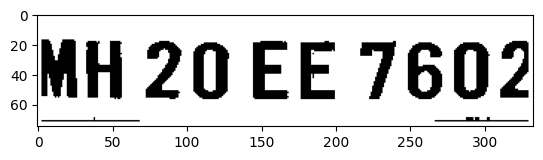

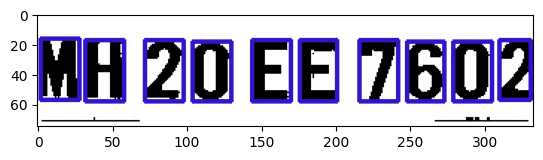

In [89]:
# Let's see the segmented characters
char = segment_characters(plate)

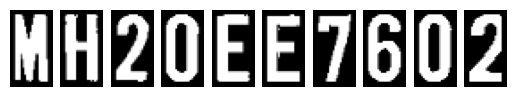

In [90]:
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(char[i], cmap='gray')
    plt.axis('off')

In [91]:
import tensorflow.keras.backend as K
train_datagen = ImageDataGenerator(rescale=1./255, width_shift_range=0.1, height_shift_range=0.1)
path = '../dataset/data'
train_generator = train_datagen.flow_from_directory(
        path+'/train',  # this is the target directory
        target_size=(28,28),  # all images will be resized to 28x28
        batch_size=1,
        class_mode='sparse')

validation_generator = train_datagen.flow_from_directory(
        path+'/val',  # this is the target directory
        target_size=(28,28),  # all images will be resized to 28x28 batch_size=1,
        class_mode='sparse')

Found 864 images belonging to 36 classes.
Found 216 images belonging to 36 classes.


## Training Data Pipeline
This block builds train/validation generators from folder-based datasets.
- `rescale=1./255` normalizes pixel values to [0, 1].
- Shift augmentation improves robustness to small spatial variations.
- `flow_from_directory` infers class labels from folder names.
- `class_mode='sparse'` is compatible with sparse categorical loss.

In [92]:
# Metrics for checking the model performance while training
def custom_f1score(y, y_pred):
  # For single-label multiclass classification, micro-F1 is equivalent to accuracy.
  y_true = tf.cast(tf.reshape(y, [-1]), tf.int32)
  y_hat = tf.cast(tf.argmax(y_pred, axis=1), tf.int32)
  return tf.reduce_mean(tf.cast(tf.equal(y_true, y_hat), tf.float32))

In [93]:
K.clear_session()
model = Sequential()
model.add(Conv2D(16, (22,22), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(Conv2D(32, (16,16), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (8,8), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (4,4), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(36, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizers.Adam(learning_rate=0.0001), metrics=[custom_f1score])

## CNN Model Definition
This CNN classifies 36 classes: digits 0-9 and letters A-Z.
- Stacked `Conv2D` layers learn low-to-high level visual features.
- `MaxPooling2D` downsamples feature maps while keeping key patterns.
- `Dropout(0.4)` helps reduce overfitting.
- The final `Dense(36, softmax)` outputs class probabilities.
- The model is optimized with Adam and sparse categorical cross-entropy.

In [94]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │        23,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,268 (2.89 MB)

 Trainable params: 757,268 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

In [95]:
class stop_training_callback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    metric = logs.get('val_custom_f1score')
    if metric is not None and metric > 0.99:
      self.model.stop_training = True

In [96]:
batch_size = 1
callbacks = [stop_training_callback()]
model.fit(
      train_generator,
      steps_per_epoch = train_generator.samples // batch_size,
      validation_data = validation_generator, 
      epochs = 80, verbose=1, callbacks=callbacks)

Epoch 1/80
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - custom_f1score: 0.1331 - loss: 3.1624 - val_custom_f1score: 0.4182 - val_loss: 1.9589
Epoch 2/80
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - custom_f1score: 0.5683 - loss: 1.4380 - val_custom_f1score: 0.7738 - val_loss: 0.6788
Epoch 3/80
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - custom_f1score: 0.7743 - loss: 0.6916 - val_custom_f1score: 0.8274 - val_loss: 0.5644
Epoch 4/80
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - custom_f1score: 0.8438 - loss: 0.4625 - val_custom_f1score: 0.8899 - val_loss: 0.3388
Epoch 5/80
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - custom_f1score: 0.9028 - loss: 0.3105 - val_custom_f1score: 0.9375 - val_loss: 0.2339
Epoch 6/80
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - custom_f1score: 0.9005 - loss: 0.2927 - val_custom_f1score: 0.8869 - val_loss: 0.3632
Epoch 7/80
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - custom_f1score: 0.9317 - loss: 0.2269 - val_custom_f1score: 0.9182 - val_loss: 0.2318
Epoch 8/80
864/864 ━

## Model Training Block
This block trains the CNN on segmented character images.
- `steps_per_epoch` controls the number of training steps per epoch.
- `validation_data` evaluates the model on the validation split.
- Early stopping logic in the callback saves time when validation performance is high.
- `model.fit(...)` is used (modern API replacement for deprecated `fit_generator`).

In [101]:
def fix_dimension(img): 
    new_img = np.zeros((28,28,3))
    for i in range(3):
        new_img[:,:,i] = img
    return new_img

def show_results():
    dic = {}
    characters = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    for i,c in enumerate(characters):
        dic[i] = c

    output = []
    for i,ch in enumerate(char): #iterating over the characters
        img_ = cv2.resize(ch, (28,28), interpolation=cv2.INTER_AREA)
        img = fix_dimension(img_)
        img = img.reshape(1,28,28,3) #preparing image for the model
        probs = model.predict(img, verbose=0)
        y_ = int(np.argmax(probs, axis=1)[0]) # predicting the class index
        character = dic[y_]
        output.append(character) #storing the result in a list
        
    plate_number = ''.join(output)
    
    return plate_number

print(show_results())

MH20EE7602


## Plate Text Inference Block
`show_results` predicts each segmented character and builds the final plate text.
- Each character is resized and reshaped to `(1, 28, 28, 3)`.
- `model.predict` outputs probabilities over 36 classes.
- `argmax` selects the most likely class index.
- The class index is mapped to `0-9` and `A-Z`, then concatenated.

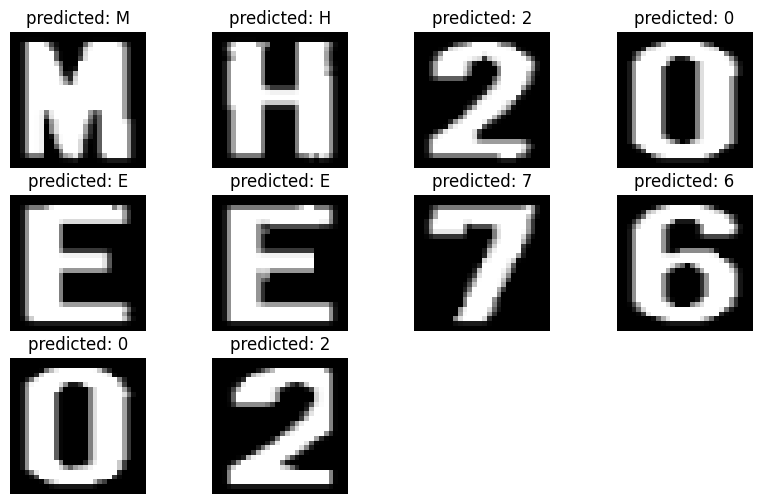

In [105]:
# Segmented characters and their predicted value.
plt.figure(figsize=(10,6))
predicted_text = show_results()
for i, ch in enumerate(char):
    char_img = cv2.resize(ch, (28,28), interpolation=cv2.INTER_AREA)
    plt.subplot(3,4,i+1)
    plt.imshow(char_img, cmap='gray')
    plt.title(f'predicted: {predicted_text[i]}')
    plt.axis('off')
plt.show()

## Final Visualization Block
The final step overlays the predicted plate text on the original image.
- Reload the source image to avoid accidental variable overwrite from previous cells.
- Call `detect_plate(source_img, plate_number)` to render text near the plate.
- Display the final annotated image for visual verification.

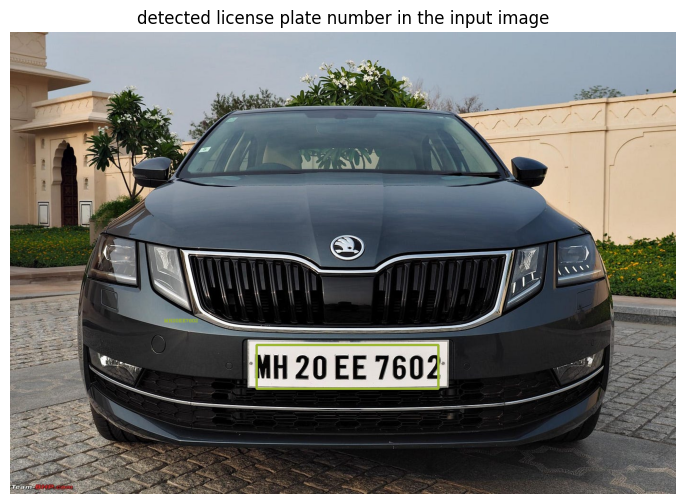

In [106]:
plate_number = show_results()
source_img = cv2.imread('../dataset/car.jpg')
output_img, plate = detect_plate(source_img, plate_number)
display(output_img, 'detected license plate number in the input image')